In [70]:
# ============================================================
# Week 3: Machine Learning Dataset Preparation
# Project: ExoHabit-AI
# ============================================================

# ------------------------------------------------------------
# 1. Import Libraries
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_style("whitegrid")

# ------------------------------------------------------------
# 2. Load Dataset
# ------------------------------------------------------------
df = pd.read_csv("../data/processed/exoplanet_cleaned.csv")

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (39212, 126)


,rowid,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,default_flag,...,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec,st_spectype_simple,habitability_score,stellar_compatibility
0,0.000000,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,1.0,...,0.125,0.014286,0.166667,0.0,0.0,0.0,0.0,G,0.345322,0.578802
1,0.000026,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,0.0,...,0.125,0.014286,0.166667,0.0,0.0,0.0,0.0,G,0.345322,0.576469
2,0.000051,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,0.0,...,0.125,0.014286,0.166667,0.0,0.0,0.0,0.0,G,0.345322,0.591862
3,0.000077,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,0.0,...,0.000,0.014286,0.083333,0.0,0.0,0.0,0.0,K,0.345322,0.569365
4,0.000102,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,1.0,...,0.000,0.014286,0.083333,0.0,0.0,0.0,0.0,G,0.345322,0.567120


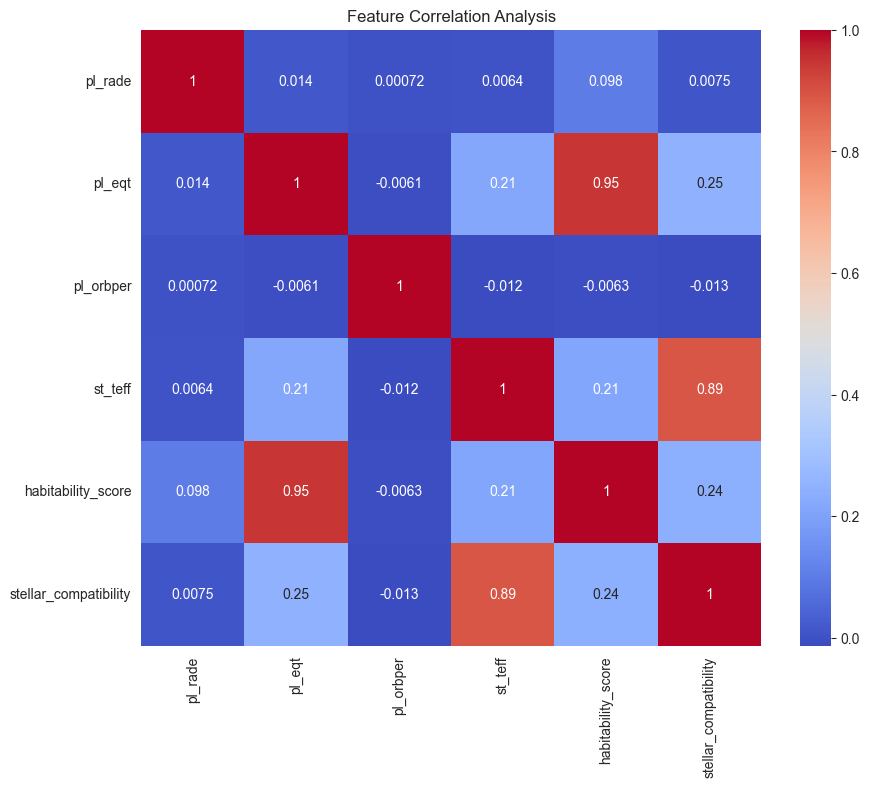

In [71]:
# ------------------------------------------------------------
# 3. Correlation Analysis
# ------------------------------------------------------------
plt.figure(figsize=(10,8))
sns.heatmap(
    df[['pl_rade','pl_eqt','pl_orbper',
        'st_teff','habitability_score',
        'stellar_compatibility']].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation Analysis")
plt.show()


In [72]:
# ------------------------------------------------------------
# 4. Define Target Variable (Quantile-Based Threshold)
# ------------------------------------------------------------

# Define top 15% planets as habitable
threshold = df['habitability_score'].quantile(0.85)

df['habitable'] = (df['habitability_score'] > threshold).astype(int)

print("Threshold Used:", threshold)
print("\nClass Distribution:")
print(df['habitable'].value_counts())


Threshold Used: 0.36773176036325106

Class Distribution:
habitable
0    33330
1     5882
Name: count, dtype: int64


In [73]:
# ------------------------------------------------------------
# 5. Feature Selection
# ------------------------------------------------------------
num_cols = ['pl_rade', 'pl_eqt', 'pl_orbper', 'stellar_compatibility']
cat_cols = ['st_spectype_simple']

X = df[num_cols + cat_cols]
y = df['habitable']


In [74]:
# ------------------------------------------------------------
# 6. Train-Test Split (Stratified)
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (31369, 5)
Testing Shape: (7843, 5)


In [75]:
# ------------------------------------------------------------
# 7. Preprocessing Pipeline
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed Training Shape:", X_train_processed.shape)


Processed Training Shape: (31369, 15)


In [76]:
# ------------------------------------------------------------
# 8. Get Feature Names (Professional Step)
# ------------------------------------------------------------
feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

X_train_df.head()


,num__pl_rade,num__pl_eqt,num__pl_orbper,num__stellar_compatibility,cat__st_spectype_simple_A,cat__st_spectype_simple_B,cat__st_spectype_simple_D,cat__st_spectype_simple_F,cat__st_spectype_simple_G,cat__st_spectype_simple_K,cat__st_spectype_simple_L,cat__st_spectype_simple_M,cat__st_spectype_simple_T,cat__st_spectype_simple_W,cat__st_spectype_simple_m
0,-0.036500,-0.126464,-0.006027,-2.508144,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.033538,-0.126464,-0.006116,0.499325,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.027569,-0.126464,-0.006120,0.348716,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.025548,2.191719,-0.006120,-0.333730,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.042362,0.116824,-0.006118,0.160455,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [77]:
# ------------------------------------------------------------
# 9. Save Pipeline & Datasets
# ------------------------------------------------------------

os.makedirs("../data/processed", exist_ok=True)

# Save fitted preprocessing pipeline
joblib.dump(preprocessor, "../data/processed/preprocessing_pipeline.pkl")

# Save split datasets
X_train.to_csv("../data/processed/X_train.csv", index=False)
X_test.to_csv("../data/processed/X_test.csv", index=False)
y_train.to_csv("../data/processed/y_train.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)

print("Week 3 preprocessing completed successfully.")


Week 3 preprocessing completed successfully.


- Domain-based features were selected using correlation analysis.
- A quantile-based threshold was used to define habitability.
- Stratified train-test split preserved class distribution.
- ColumnTransformer was used to prevent data leakage.
- Preprocessing pipeline was saved for future model training.
